In [14]:
import pandas as pd

In [15]:
df=pd.read_csv("dataset_sig_phq9.csv")

In [16]:
df.columns

Index(['PHQ_class', 'age_class', 'B6_relationship_with_family', 'weight_class',
       'D3_device', 'D4_content', 'D5_parents_screen_time',
       'F1_academic_satisfaction', 'G1_mood_swings',
       'G2_anxious_without_device', 'G4_isolation', 'G5_negative_mental',
       'G6_panic_attack', 'H1_mobile_while_eating'],
      dtype='str')

## Multinomial Logistic Regression — Target: `PHQ_class`

In [17]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [18]:
# 1. Prepare features and target
target = 'PHQ_class'
features = [c for c in df.columns if c != target]

X = df[features].copy()
y = df[target].copy()

# Encode every categorical column with a fresh LabelEncoder
encoders = {}
for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

le_target = LabelEncoder()
y_enc = le_target.fit_transform(y.astype(str))
class_names = le_target.classes_

print("Classes:", class_names)
print("Encoded labels:", np.unique(y_enc))

Classes: ['Mild depressive' 'Minimal depressive' 'Moderate depressive'
 'Moderately Severe depressive' 'Severe depressive']
Encoded labels: [0 1 2 3 4]


In [19]:
# 2. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

Train size: 361  |  Test size: 91


In [20]:
# 3. Fit Multinomial Logistic Regression
mlr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
mlr.fit(X_train, y_train)
y_pred = mlr.predict(X_test)

# 4. Evaluation
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

Test Accuracy: 0.3736 (37.36%)

Classification Report:
                              precision    recall  f1-score   support

             Mild depressive       0.38      0.48      0.43        33
          Minimal depressive       0.47      0.47      0.47        17
         Moderate depressive       0.33      0.34      0.34        29
Moderately Severe depressive       0.00      0.00      0.00         9
           Severe depressive       0.00      0.00      0.00         3

                    accuracy                           0.37        91
                   macro avg       0.24      0.26      0.25        91
                weighted avg       0.33      0.37      0.35        91



### Odds Ratios (per class vs. reference)

In [21]:
# Odds Ratios
# OR = exp(coefficient); OR > 1 → increases odds of that class, < 1 → decreases
odds_ratio_df = pd.DataFrame(
    np.exp(mlr.coef_),
    index=class_names,
    columns=features
).T

print("Odds Ratios per class (rows=features, columns=PHQ_class classes):\n")
print(odds_ratio_df.round(4).to_string())

Odds Ratios per class (rows=features, columns=PHQ_class classes):

                             Mild depressive  Minimal depressive  Moderate depressive  Moderately Severe depressive  Severe depressive
age_class                             0.7877              2.0677               0.8973                        0.8436             0.8111
B6_relationship_with_family           0.5465              0.6813               0.9088                        0.8918             3.3141
weight_class                          0.9859              0.8627               0.7865                        1.3322             1.1221
D3_device                             0.9451              1.3883               0.7319                        1.3441             0.7748
D4_content                            0.9409              1.0491               0.9719                        1.0528             0.9900
D5_parents_screen_time                1.1077              0.5206               1.5426                        0.9632        

In [22]:
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import MNLogit

# Refit using statsmodels to get standard errors, p-values, and CIs
X_sm = sm.add_constant(X.values.astype(float))
feature_names_sm = ['const'] + features

mnl = MNLogit(y_enc, X_sm)
result = mnl.fit(method='bfgs', maxiter=2000, disp=False)

ref_class = class_names[0]
eq_classes = class_names[1:]

rows = []
for eq_idx, cls in enumerate(eq_classes):
    coefs = result.params[:, eq_idx]
    se    = result.bse[:, eq_idx]
    pvals = result.pvalues[:, eq_idx]

    for feat_idx, feat in enumerate(feature_names_sm):
        if feat == 'const':
            continue
        b = coefs[feat_idx]
        s = se[feat_idx]
        rows.append({
            'Class (vs. reference)': f"{cls}  vs.  {ref_class}",
            'Feature':               feat,
            'Odds Ratio':            round(np.exp(b), 4),
            'Lower 95% CI':          round(np.exp(b - 1.96 * s), 4),
            'Upper 95% CI':          round(np.exp(b + 1.96 * s), 4),
            'p-value':               round(pvals[feat_idx], 4),
        })

or_table = pd.DataFrame(rows)

pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', '{:.4f}'.format)
print("Odds Ratio Table — Multinomial Logistic Regression")
print(f"Reference class: '{ref_class}'\n")
print(or_table.to_string(index=False))


Odds Ratio Table — Multinomial Logistic Regression
Reference class: 'Mild depressive'

                             Class (vs. reference)                     Feature  Odds Ratio  Lower 95% CI  Upper 95% CI  p-value
          Minimal depressive  vs.  Mild depressive                   age_class      2.2793        1.4529        3.5758   0.0003
          Minimal depressive  vs.  Mild depressive B6_relationship_with_family      1.2524        0.5476        2.8646   0.5939
          Minimal depressive  vs.  Mild depressive                weight_class      0.8761        0.5954        1.2891   0.5020
          Minimal depressive  vs.  Mild depressive                   D3_device      1.9655        1.0608        3.6419   0.0318
          Minimal depressive  vs.  Mild depressive                  D4_content      1.0855        0.9668        1.2188   0.1649
          Minimal depressive  vs.  Mild depressive      D5_parents_screen_time      0.5234        0.2705        1.0129   0.0546
          Minimal

In [23]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

output_pdf = "report_v3/or_table_mlr_phq9.pdf"

col_widths = [0.32, 0.22, 0.12, 0.13, 0.13, 0.10]
row_height = 0.32
rows_per_page = 40

pages = [or_table.iloc[i:i+rows_per_page] for i in range(0, len(or_table), rows_per_page)]

with PdfPages(output_pdf) as pdf:
    for page_num, page_df in enumerate(pages):
        n_rows = len(page_df)
        fig_h = 0.55 + n_rows * row_height + 1.2
        fig, ax = plt.subplots(figsize=(14, fig_h))
        ax.axis('off')

        col_labels = or_table.columns.tolist()

        tbl = ax.table(
            cellText=page_df.values.tolist(),
            colLabels=col_labels,
            colWidths=col_widths,
            loc='center',
            cellLoc='center',
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(7.5)
        tbl.scale(1, 1.4)

        for col_idx in range(len(col_labels)):
            cell = tbl[0, col_idx]
            cell.set_facecolor('#2c3e50')
            cell.set_text_props(color='white', fontweight='bold')

        for row_idx in range(1, n_rows + 1):
            for col_idx in range(len(col_labels)):
                cell = tbl[row_idx, col_idx]
                cell.set_facecolor('#f2f2f2' if row_idx % 2 == 0 else 'white')
                cell.set_edgecolor('#cccccc')

        total_pages = len(pages)
        ax.set_title(
            f"Odds Ratio Table — Multinomial Logistic Regression (PHQ_class)\n"
            f"Reference class: '{ref_class}'   |   Page {page_num+1} of {total_pages}",
            fontsize=10, fontweight='bold', pad=12
        )
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

print(f"Saved: {output_pdf}  ({len(pages)} page(s), {len(or_table)} rows)")


Saved: report_v3/or_table_mlr_phq9.pdf  (2 page(s), 52 rows)


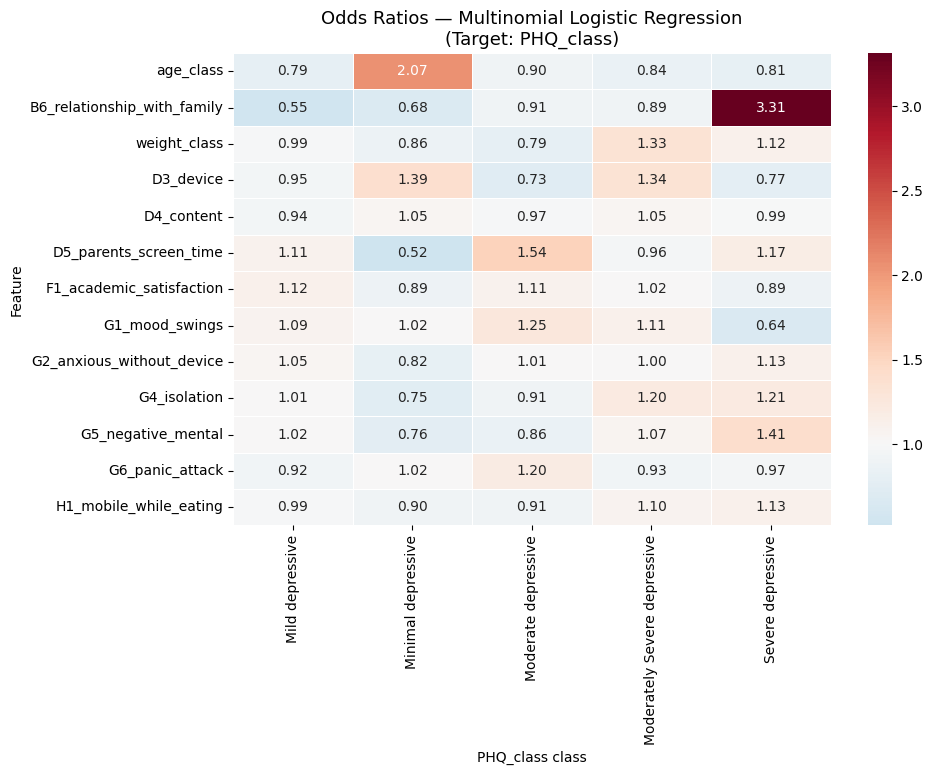

In [24]:
# Odds Ratio Heatmap
import seaborn as sns

fig, ax = plt.subplots(figsize=(max(8, len(class_names) * 2), len(features) * 0.45 + 2))
sns.heatmap(
    odds_ratio_df,
    annot=True, fmt=".2f",
    center=1.0,
    cmap="RdBu_r",
    linewidths=0.4,
    ax=ax
)
ax.set_title("Odds Ratios — Multinomial Logistic Regression\n(Target: PHQ_class)", fontsize=13)
ax.set_xlabel("PHQ_class class")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

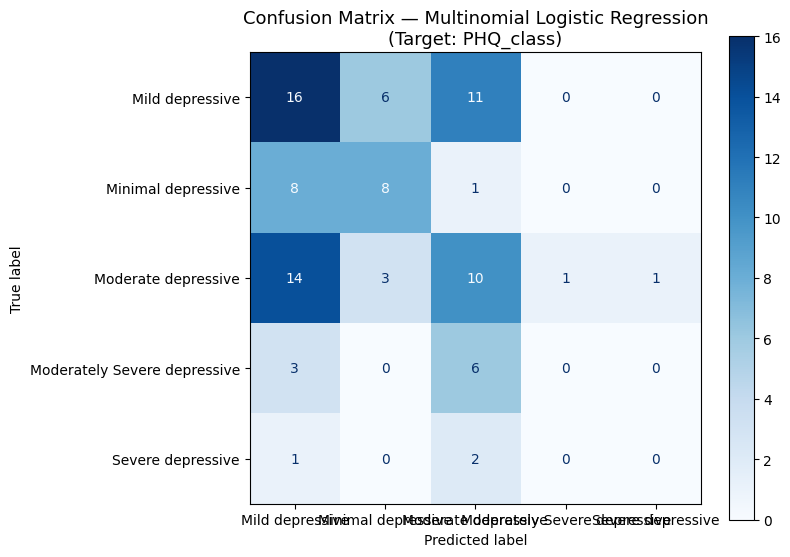

In [25]:
# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title("Confusion Matrix — Multinomial Logistic Regression\n(Target: PHQ_class)", fontsize=13)
plt.tight_layout()
plt.show()

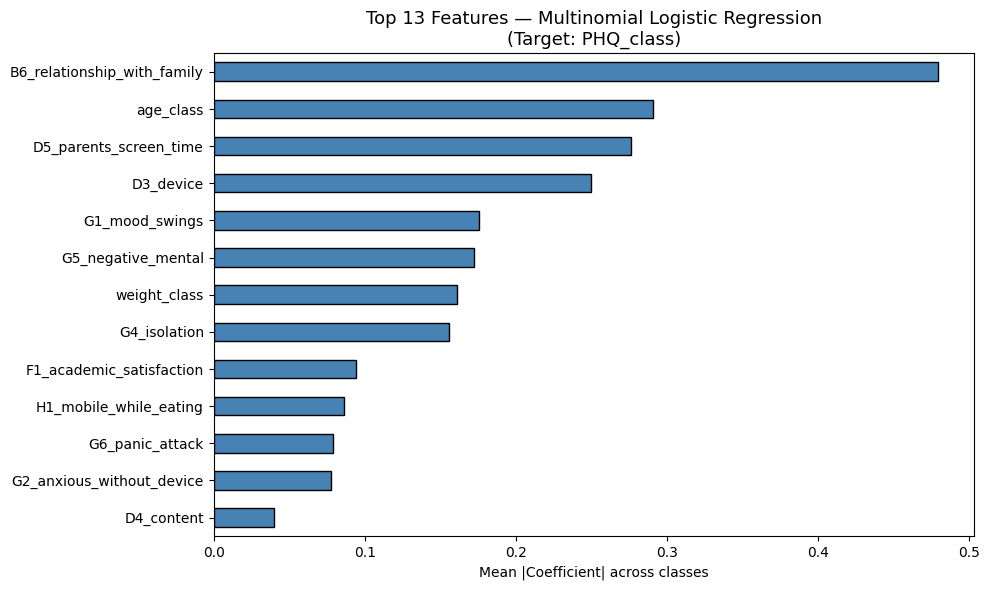


Top 13 features by mean absolute coefficient:
                             mean_abs
B6_relationship_with_family    0.4793
age_class                      0.2906
D5_parents_screen_time         0.2761
D3_device                      0.2495
G1_mood_swings                 0.1760
G5_negative_mental             0.1721
weight_class                   0.1608
G4_isolation                   0.1557
F1_academic_satisfaction       0.0942
H1_mobile_while_eating         0.0862
G6_panic_attack                0.0793
G2_anxious_without_device      0.0775
D4_content                     0.0398


In [26]:
# 6. Feature Importance (Coefficients)
coef_df = pd.DataFrame(
    mlr.coef_,
    index=class_names,
    columns=features
).T

# Mean absolute coefficient across classes → overall importance
coef_df['mean_abs'] = coef_df.abs().mean(axis=1)
coef_df_sorted = coef_df.sort_values('mean_abs', ascending=False)

top_n = min(20, len(features))
fig, ax = plt.subplots(figsize=(10, 6))
coef_df_sorted['mean_abs'].head(top_n).sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='black'
)
ax.set_xlabel("Mean |Coefficient| across classes")
ax.set_title(f"Top {top_n} Features — Multinomial Logistic Regression\n(Target: PHQ_class)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nTop {top_n} features by mean absolute coefficient:")
print(coef_df_sorted[['mean_abs']].head(top_n).to_string())